Test the perturbed slab model created.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
from fields.slab_bfield_one_pert import SlabBfieldOnePert
from pyoculus.maps import ToroidalBfieldSection
from pyoculus.solvers import PoincarePlot, FixedPoint
from pyoculus.solvers import Manifold
import matplotlib.pyplot as plt

#### Create the magnetic field:

In [2]:
field = SlabBfieldOnePert(
    m=2,
    n=0,
    delta=0.01,
    iota_prime=1.0,
    x0=0.5,
)

xs = field.x0 + field.n / (field.iota_prime * field.m)
print("The island will be situated at x_s =", xs)

The island will be situated at x_s = 0.5


#### Create the map:

In [3]:
map = ToroidalBfieldSection(field)

#### Create Poincaré plot:

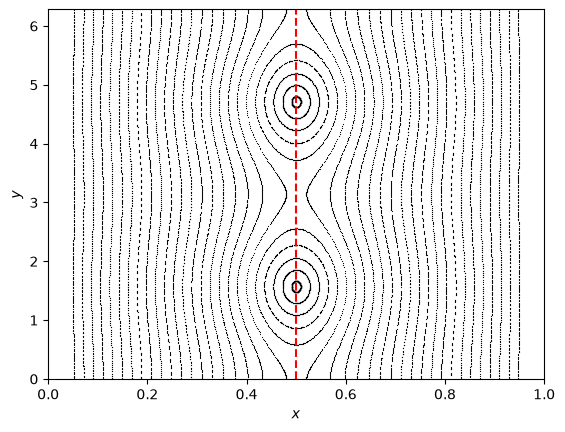

In [4]:
pplot = PoincarePlot.with_segments(
    map,
    np.array([
        [0.05, np.pi / 2],
        [0.95, np.pi / 2],
        [0.05, 3 * np.pi / 2],
        [0.95, 3 * np.pi / 2],
    ]),
    neps=[50, 50],
    connected=False,
)

# Follow each initial condition for 200 crossings
pplot.compute(npts=150)

# Plot directly in (x,y) coordinates
fig, ax = pplot.plot(plottype=None) # plottypeNone to directly plot in the coordinates of the map

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 2*np.pi)

ax.axvline(
    xs,
    linestyle="--",
    label=rf"$x_s={xs:.3f}$",
    color="r"
)

plt.show()

#### Find fixed points:

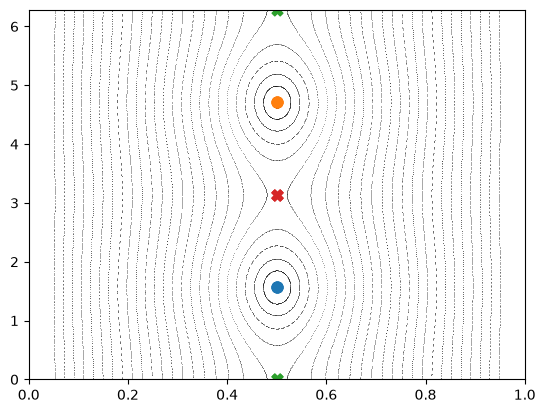

In [12]:
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[0, 1.],
    ylim=[0, 2*np.pi],
    plottype=None
)


fp = FixedPoint(map)

# Elliptic FP / O-points:
result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.45, 1.3]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.45, 4.5]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

# Hyperbolic FP / X-points:
result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.45, 0.5]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)

result = fp.find_with_iota(
    n = field.n,
    m = field.m,
    guess = np.array([0.45, 3]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    s=60,
    plottype=None
)


plt.show()

#### Wrong cases:

```fp.find(t=t,...)``` doesn't always work: sometimes we stumble upon t-cycles that aren't fixed points.

[[0.5        6.28318531]
 [0.5        6.28318531]]
[[5.00000000e-01 1.77635684e-14]
 [5.00000000e-01 2.23434919e-14]
 [5.00000000e-01 3.54880897e-14]]
[[0.16652463 5.50342181]
 [0.17024208 3.38506276]
 [0.16303324 1.28985923]
 [0.16652463 5.50342181]]


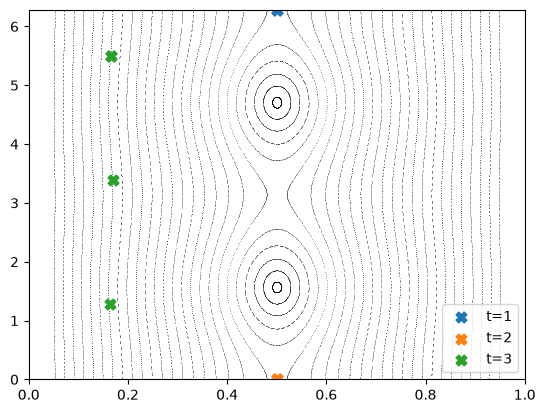

In [6]:
guess = np.array([0.45, 6])
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[0, 1.],
    ylim=[0, 2*np.pi],
    plottype=None
)

for t in [1,2,3]:
    fp = FixedPoint(map)
    result = fp.find(
        t=t,                    # t-order fixed points
        guess=guess,
        method="scipy.root"
    ) 
    print(result.coords)     

    fp.plot(
        fig=fig,
        ax=ax,
        marker="X",
        s=60,
        label=f"t={t}",
        plottype=None
    )

plt.legend(loc="lower right")
plt.show()


#### Find manifolds

In [7]:
fp1 = FixedPoint(map)
fp1.find_with_iota(n = field.n, m = field.m, guess = np.array([0.45, 0.5]), method="scipy.root")   

fp2 = FixedPoint(map)
fp2.find_with_iota(n = field.n, m = field.m, guess = np.array([0.45, 3]), method="scipy.root")   

X1: [5.00000000e-01 1.28663927e-14]
X2: [0.5        3.14159265]
X1 residue: -0.4394288926728984
X2 residue: -0.439428892672898
X1 eigenvalues: [0.28822691+0.j 3.46948866+0.j]
X2 eigenvalues: [3.46948866+0.j 0.28822691+0.j]


c:\Users\mirei\OneDrive - epfl.ch\MA3\SdS\local\.venv\Lib\site-packages\matplotlib\transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)
c:\Users\mirei\OneDrive - epfl.ch\MA3\SdS\local\.venv\Lib\site-packages\matplotlib\text.py:863: ComplexWarning: Casting complex values to real discards the imaginary part
  posx = float(self.convert_xunits(x))
c:\Users\mirei\OneDrive - epfl.ch\MA3\SdS\local\.venv\Lib\site-packages\matplotlib\text.py:864: ComplexWarning: Casting complex values to real discards the imaginary part
  posy = float(self.convert_yunits(y))
c:\Users\mirei\OneDrive - epfl.ch\MA3\SdS\local\.venv\Lib\site-packages\matplotlib\text.py:1012: ComplexWarning: Casting complex values to real discards the imaginary part
  x = float(self.convert_xunits(self._x))
c:\Users\mirei\OneDrive - epfl.ch\MA3\SdS\local\.venv\Lib\site-packages\matplotlib\text.py:1013: ComplexWarning: Casting complex values to real disca

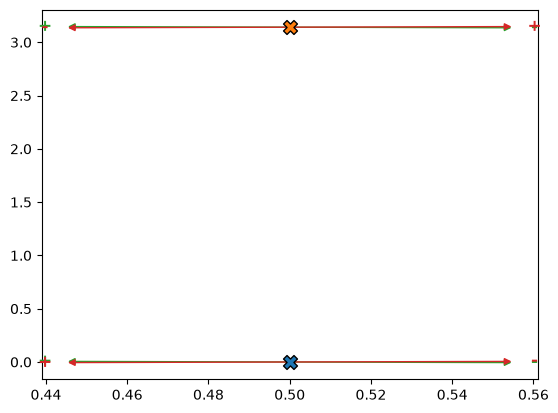

In [8]:
print("X1:", fp1.coords[0])
print("X2:", fp2.coords[0])

print("X1 residue:", fp1.GreenesResidue)
print("X2 residue:", fp2.GreenesResidue)

print("X1 eigenvalues:", fp1.eigenvalues)
print("X2 eigenvalues:", fp2.eigenvalues)

Manifold.show_directions(fp1, fp2)
plt.show()

In [9]:
manifold1 = Manifold(map, fp1)
manifold2 = Manifold(map, fp2)

# Convert numerically real eigenvectors to real dtype
manifold1.vector_s = np.real_if_close(manifold1.vector_s)
manifold1.vector_u = np.real_if_close(manifold1.vector_u)
manifold2.vector_s = np.real_if_close(manifold2.vector_s)
manifold2.vector_u = np.real_if_close(manifold2.vector_u)

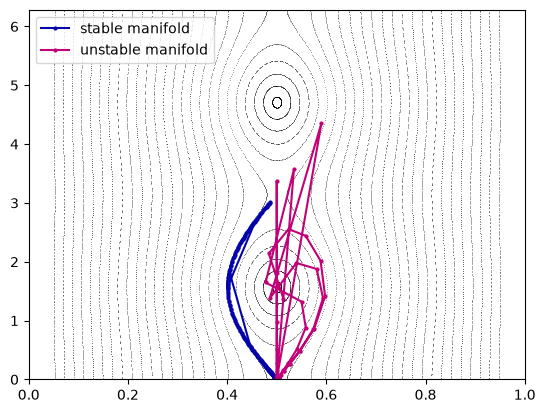

In [10]:
manifold1.compute(eps_s=1e-5, eps_u=1e-10, nint_s=10, nint_u=3)
# manifold1.find_clinic_single(guess_eps_s=1e-3, guess_eps_u=1e-3)

# manifold2.compute(eps_s=1e-5, eps_u=1e-5, nint_s=10, nint_u=10)
# manifold2.find_clinic_single(guess_eps_s=1e-3, guess_eps_u=1e-3)

fig, ax = pplot.plot(marker=".", s=0.5, xlim=[0, 1.], ylim=[0, 2*np.pi], plottype=None)

manifold1.plot("both", ax=ax)
manifold1.plot_clinics(ax=ax)
# manifold2.plot("both", ax=ax)
# manifold2.plot_clinics(ax=ax)
ax.scatter(fp1.coords[0][0], fp1.coords[0][1], marker='o')
ax.legend(loc="upper left")

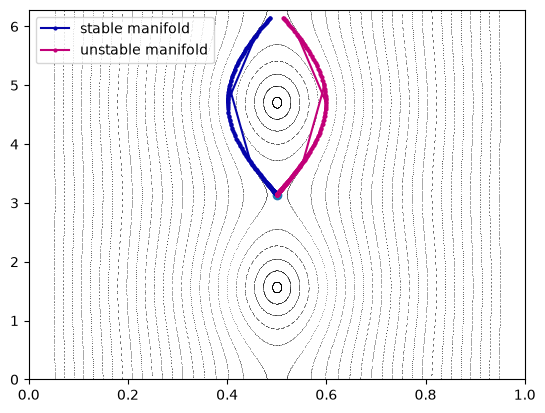

In [11]:
# manifold1.compute(nint_s=10, nint_u=3)
manifold2.compute(eps_s=1e-5, eps_u=1e-5, nint_s=10, nint_u=10)
# manifold1.find_clinic_single(guess_eps_s=1e-3, guess_eps_u=1e-3)
# manifold2.find_clinic_single(guess_eps_s=1e-3, guess_eps_u=1e-3)

fig, ax = pplot.plot(marker=".", s=0.5, xlim=[0, 1.], ylim=[0, 2*np.pi], plottype=None)

# manifold1.plot("both", ax=ax)
# manifold1.plot_clinics(ax=ax)
manifold2.plot("both", ax=ax)
# manifold2.plot_clinics(ax=ax)
ax.scatter(fp2.coords[0][0], fp2.coords[0][1], marker='o')
ax.legend(loc="upper left")

Use find_clinics_exhaustive() - mirar una mica més ne detall què fa exactament, però en prinicipi hauria de trobar totes les intereccions que necessitem, no només una com fa find_clinic_single().

Com que estem treballant amb heteroclinics, hem de donar 2 fp. Donar un O-point ajuda al programa.

Per calcular els manifolds, utilitzar compute_adaptive() (pull from Ralf) - comprovar resolució.